<!--TABLE OF CONTENTS-->
Contents:
- [Decision trees](#Decision-trees)
  - [Visualizing decision tree](#Visualizing-decision-tree)
  - [Visualizing decision boundary](#Visualizing-decision-boundary)
  - [Hyperparameter tuning for trees](#Hyperparameter-tuning-for-trees)
  - [Feature importance](#Feature-importance)
  - [Decision tree for regression](#Decision-tree-for-regression)
  - [Practice question](#Practice-question)
- [Ensemble Methods](#Ensemble-Methods)
  - [Voting classifiers](#Voting-classifiers)
  - [Bagging](#Bagging)
    - [Out-of-Bag evaluation](#Out-of-Bag-evaluation)
    - [Random Forest](#Random-Forest)
  - [Boosting](#Boosting)
    - [Gradient Boosting](#Gradient-Boosting)
    - [XGBoost](#XGBoost)
    - [LightGBM](#LightGBM)
    - [CatBoost](#CatBoost)
- [Adjusting weights of the minority class](#Adjusting-weights-of-the-minority-class)
  - [Key points](#Key-points)

# Decision trees

Part of this section is from: https://jakevdp.github.io/PythonDataScienceHandbook/05.08-random-forests.html

First we will use a decision tree for classification of a small synthetic dataset.
As we have done before, we will use `make_blobs` method from `sklearn` to generate our data. 

`make_blobs()` has a parameter *n_features* (the number of features for each sample), and its default value is 2.
We will be creating our data *X* with 2 features, and *y* will correspond to the label of the class to which a point belongs. 
Then, we will visualize our data with scatter plot. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

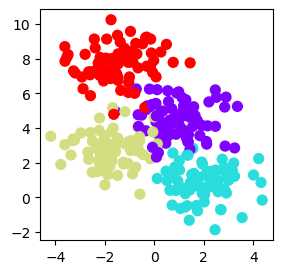

In [2]:
from sklearn.datasets import make_blobs, make_classification

X, y = make_blobs(n_samples=300, centers=4, random_state=0, cluster_std=1)
fig = plt.figure(figsize=(3,3))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow');

Note that we have used one additional parameter in the scatter plot, *cmap*, which defined the colormap. Here are some different choices for the color scheme: 
https://matplotlib.org/stable/tutorials/colors/colormaps.html

Let's confirm the size of our data.

In [3]:
X.shape

(300, 2)

Let's see the distribution of classes:

In [4]:
pd.Series(y).value_counts()

1    75
3    75
0    75
2    75
Name: count, dtype: int64

Next we will fit a decision tree for classification.
The full list of the parameters is available in the documentation: \
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


Note that by default, the criterion for finding the best splits is Gini index.
The parameter which controls this is 
*criterion* , default=*gini*, it can be set to *entropy*.
Let's first plot a smaller tree for easier visualization, we will set the depth of the tree as 3.

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

The decision classifier has an attribute called *tree_* which allows access to low level attributes such as *node_count*,
the total number of nodes, and *max_depth*, the maximal depth of the tree. It also stores the entire binary tree structure,
More details in:

https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html
    
Let's see the total number of nodes and the depth of a tree.

In [6]:
print('number of nodes is ', tree.tree_.node_count)
print('depth of the tree is ', tree.tree_.max_depth)

number of nodes is  9
depth of the tree is  3


## Visualizing decision tree

Let's now see our constructed tree.

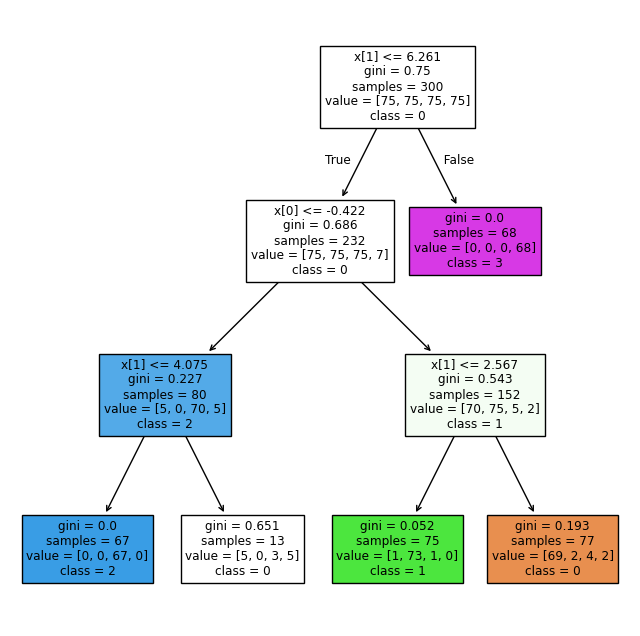

In [7]:
plt.figure(figsize=(8,8))
plot_tree(tree, class_names=['0','1','2','3'], filled=True)
plt.show()

Each box in the plot represents a node. Let's look at the root node output.

First line of the output: X[1]<=6.6261 is the first split. Based on the result, it either follows the true (left) or the false (right) path.

*gini = 0.75*: The gini score is a metric that quantifies the purity of the node/leaf. A gini score greater than zero implies that the samples contained within that node belong to different classes. A gini score of 0 means that the node is pure, that within that node only a single class of data points exist. 
Notice that we have a gini score greater than zero. Therefore, we know that the data points contained within the root node belong to different classes. For k classes, the maximum Gini index is (k − 1) / k, so for classes this gives exactly 0.75, as we have.

*samples = 300*: Since our dataset set contains 300  data points, this value is set to 300.

*value = [75, 75, 75, 75]*: The value list tells us how many samples at the given node fall into each class. The first element of the list shows the number of points that belong to class 0, the second element of the list shows the number of points that belong to class 1,... Notice how this node is not a pure one since different types of classes are contained within the same node. We knew this already from the gini score.

*class* = 0: The class value shows the prediction a given node will make and it can be determined from the value list. Whichever class occurs the most within the node will be selected as the class value. If the decision tree were to end at the root node, it would predict that all 300 samples belonged to class 0. 
Of course this makes no sense, since there is an equal number of samples for each class, but the decision tree is programmed to choose the first class on the list if there is an equal number of samples for each class.

Note that for this exercise, we are not splitting the data into train and test. 
We will not be evaluating the classifier performance on the test set, or tuning the hyperparameters.
The goal of this part is only to visualize and understand the tree performance.

## Visualizing decision boundary

Next, we will use the visualize the decision regions just like we did for the other classifiers.

Let's now see our classifier.

Text(0.5, 1.0, 'Decision Tree of depth 3')

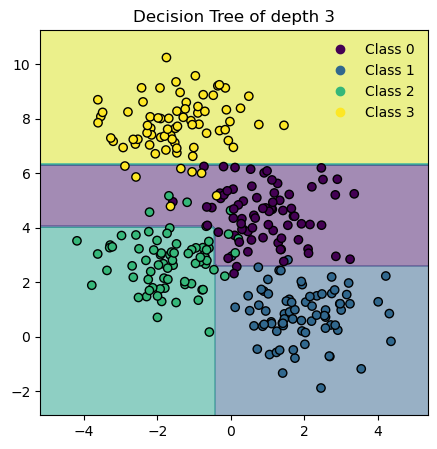

In [8]:
from sklearn.inspection import DecisionBoundaryDisplay
plt.figure(figsize=(5,5))
ax = plt.axes()
disp = DecisionBoundaryDisplay.from_estimator(tree, X, response_method="predict", alpha=0.5, ax=ax)
scatter=ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
handles, labels = scatter.legend_elements()
ax.legend(handles=handles, labels=["Class " + str(k) for k in sorted(np.unique(y))], frameon=False)
ax.set_title("Decision Tree of depth 3")

Notice that the decision boundaries are perpendicular to the axes. 

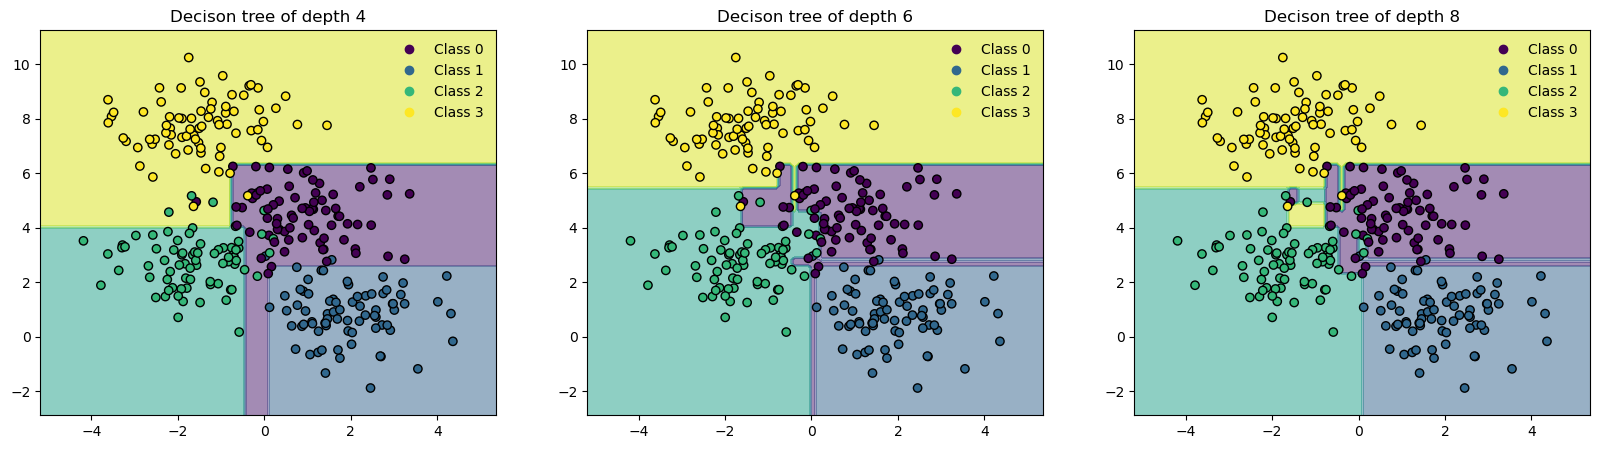

In [9]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

for depth, ax in zip(range(4,9,2), axs):
        tree = DecisionTreeClassifier(max_depth=depth)
        tree.fit(X, y)
        disp = DecisionBoundaryDisplay.from_estimator(tree, X, response_method="predict", alpha=0.5, ax=ax)
        scatter=ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
        handles, labels = scatter.legend_elements()
        ax.legend(handles=handles, labels=["Class " + str(k) for k in sorted(np.unique(y))], frameon=False)
        ax.set_title(f"Decison tree of depth {depth}")


Let's visualize decision boundaries for trees of varying depth.

Notice that as the depth increases, we tend to get very strangely shaped classification regions; 
for example, for depth 4, there is a tall and skinny purple region between the green and blue regions.
It's clear that this is less a result of the true data distribution, and more a result of the particular sampling or noise properties of the data.
That is, this decision tree, even at only 4 levels deep, is clearly over-fitting our data. Such over-fitting turns out to be a general property of decision trees: it is very easy to go too deep in the tree, and thus to fit details of the particular data rather than the overall properties of the distributions they are drawn from. 

Another way to see this over-fitting is to look at models trained on different subsets of the data, for example, if we train two different trees, each on half of the original data.

Recall that on numpy arrays slicing (taking elements from one given index to another given index) is done [start:end:step], so taking every other element is done as X[::2] (equivalent to X[0::2]), starting from the first element, index 0. Remember that the second element has index 1.

If we do not specify the maximum depth of a tree, the default value is *None*, meaning that the nodes are expanded until all leaves are pure or until all leaves contain less than *min_samples_split* samples (which has a default value of 2).

Text(0.5, 1.0, 'Decision Tree trained on the other half of the data')

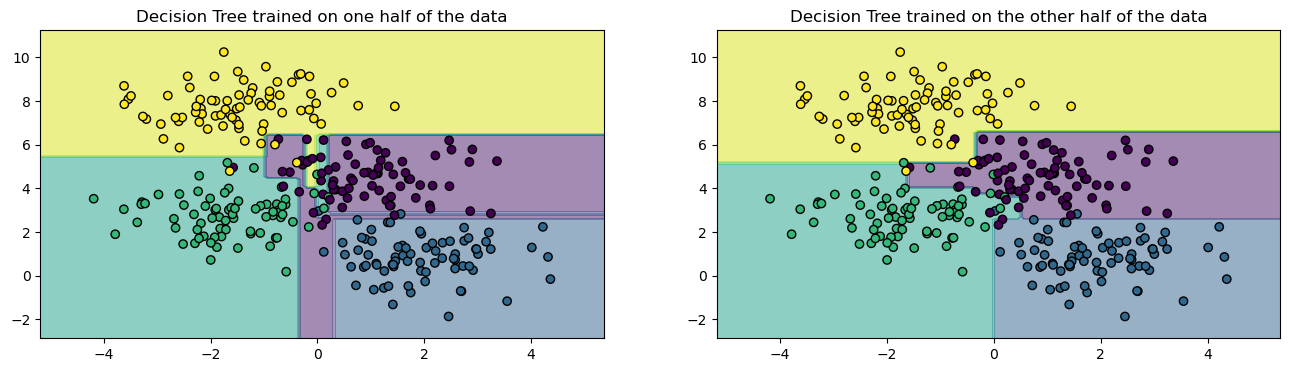

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
tree1 = DecisionTreeClassifier().fit(X[::2], y[::2])
tree2 = DecisionTreeClassifier().fit(X[1::2], y[1::2])

disp = DecisionBoundaryDisplay.from_estimator(tree1, X, response_method="predict", alpha=0.5, ax=axs[0])
scatter=axs[0].scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
axs[0].set_title("Decision Tree trained on one half of the data")

disp = DecisionBoundaryDisplay.from_estimator(tree2, X, response_method="predict", alpha=0.5, ax=axs[1])
scatter=axs[1].scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
axs[1].set_title("Decision Tree trained on the other half of the data")

It is clear that in some places, the two trees produce consistent results (e.g., in the four corners), while in other places, the two trees give very different classifications (e.g., in the regions between any two classes). The key observation is that the inconsistencies tend to happen where the classification is less certain, and thus by using information from both of these trees, we might come up with a better result. We will cover multiple treesnext. Here we see that with slightly different data set we obtain a different model, so we have a high variance with higher depth tree.

## Hyperparameter tuning for trees

Let's import the familiar dataset `breast_cancer` from sklearn datasets.

In [11]:
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

All the features are numerical. Let's check descriptive statistics.

In [12]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [13]:
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

Let's check do we have any missing data.

In [14]:
X.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

Let's split our data into test and train, leaving 20% of data for testing.

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(455, 30)
(455,)
(114, 30)
(114,)


Now, let's tune our tree using randomized search cross validation on the train set, and evaluate its performance on the test set.
We will optimize several decision tree parameters:

- *criterion* {"gini", "entropy"}, default="gini"
The function to measure the quality of a split. Supported criteria are "gini" for the Gini impurity and "entropy" for the information gain. In practice, both the Gini impurity and entropy typically yield very similar results.

- *max_depth*  specifies the maximum depth of the tree. The default is None.

- *min_samples_leaf*  int or float, default=1, specifies the minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least *min_samples_leaf training* samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.

Note that we are not doing feature scaling, since decision trees do not require it, as this is not a distance based method. As the scoring function we will use f1 score. (Recall that the metric depends on the problem we are trying to solve, so here f1 is just as an example). 

In [16]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

In [17]:
distributions= dict(max_depth=randint(1, 10), 
                    min_samples_leaf=randint(1, 10), 
                    criterion= ["gini", "entropy"] )

Above we used the `randint()` method which returns an integer number selected element from the specified range.

In [18]:
tree = DecisionTreeClassifier()
random_search = RandomizedSearchCV(tree, distributions, n_iter=20, random_state=1, cv=10, scoring='f1', n_jobs=-1)
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': <scipy.stats....00169E5A2F0E0>, 'min_samples_leaf': <scipy.stats....00169E5A23890>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionc

So above we specified that we want to test 20 different parameter combinations, where we could either use gini or entropy as the splitting criteria, the tree could be of depth between 1 and 10, and the minimum number of samples required to be at a leaf node would be a random number from the range 1 to 10.
Let's see what parameter combinations were generated. We will look at the *cv_results_* once again.

In [19]:
results = pd.DataFrame(random_search.cv_results_)

Now, let's see the value of the column with the tested parameters, *params*. We will sort the results:

In [20]:
sorted(results.params, key=lambda x: (x['criterion'], x['max_depth'], x['min_samples_leaf']))

[{'criterion': 'entropy', 'max_depth': 1, 'min_samples_leaf': 1},
 {'criterion': 'entropy', 'max_depth': 1, 'min_samples_leaf': 5},
 {'criterion': 'entropy', 'max_depth': 1, 'min_samples_leaf': 7},
 {'criterion': 'entropy', 'max_depth': 2, 'min_samples_leaf': 1},
 {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 5},
 {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 8},
 {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5},
 {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 2},
 {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 7},
 {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 7},
 {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 6},
 {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 7},
 {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 5},
 {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 9},
 {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5},
 {'criterion': 'gin

Let's see what are the best parameters:

In [21]:
random_search.best_params_

{'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 3}

And let's see what is the best f1 score of cross validation:

In [22]:
random_search.best_score_

np.float64(0.958746302985268)

Let's plot look at the evaluation metrics of our tuned tree on the test data.

In [23]:
from sklearn.metrics import classification_report
y_pred=random_search.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Let's look at our ROC plot.

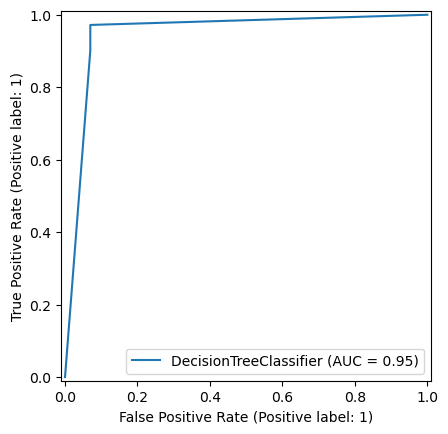

In [24]:
from sklearn.metrics import RocCurveDisplay 
RocCurveDisplay.from_estimator(random_search.best_estimator_, X_test, y_test)

Given that this is a simple problem, we have obtained very good results, with AUC of 0.95.

## Feature importance

Let us first plot a very simple tree only of depth 1.

[Text(0.5, 0.75, 'x[7] <= 0.051\nentropy = 0.952\nsamples = 455\nvalue = [169, 286]\nclass = 1'),
 Text(0.25, 0.25, 'entropy = 0.314\nsamples = 282\nvalue = [16, 266]\nclass = 1'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'entropy = 0.517\nsamples = 173\nvalue = [153, 20]\nclass = 0'),
 Text(0.625, 0.5, '  False')]

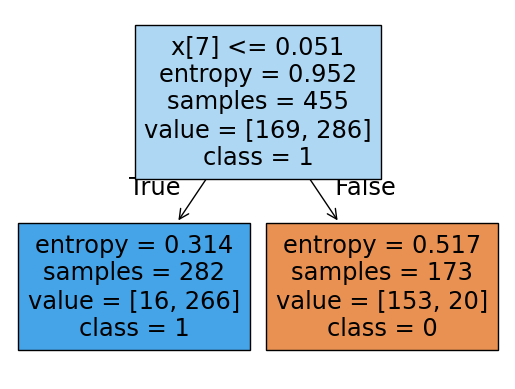

In [25]:
tree = DecisionTreeClassifier(max_depth=1, criterion='entropy').fit(X_train, y_train)
plot_tree(tree, class_names=['0','1'], filled=True)

We can see that the 8th feature was the most informative feature for the single split (the split looks at x[7]). Let's see what that feature is:

In [26]:
X.columns[7]

'mean concave points'

Instead of looking at splits for the whole tree, which can be difficult for trees of higher length, there are some useful properties that we can derive to summarize the workings of the tree. The most commonly used summary is feature importance, which rates how important each feature is for the decision a tree makes. It is a number between 0 and 1 for each feature, where 0 means "not used at all: and 1 means "perfectly predicts the target". The feature importances always sum to 1. The importance of a feature is computed as the (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance.

In [27]:
importance=random_search.best_estimator_.feature_importances_
importance

array([0.        , 0.06091857, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.72028003, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.01248274, 0.00128754,
       0.        , 0.01279121, 0.        , 0.        , 0.00186792,
       0.05448229, 0.00379717, 0.05364337, 0.        , 0.        ,
       0.        , 0.        , 0.06839111, 0.        , 0.01005805])

We can visualize the feature importances using matplotlib's horizontal bar plot *barh*:

Text(0, 0.5, 'Feature')

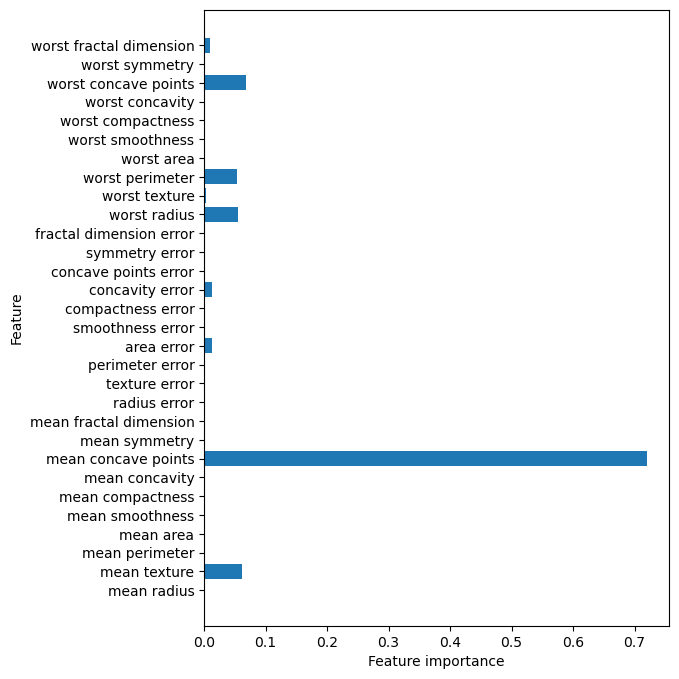

In [28]:
plt.figure(figsize=(6,8))
n_features =X.shape[1]
plt.barh(range(n_features), importance, align='center')
plt.yticks(np.arange(n_features), X.columns)
plt.xlabel('Feature importance')
plt.ylabel('Feature')

Here we see that the feature used in the top split, *mean concave points*, is by far the most important feature. This confirms our observation in analyzing the tree that the first level already separates the two classes fairly well.
However, if a feature has a low *feature_importance*, it doesn't mean that this feature is uninformative. It only means that the feature was not picked by the tree, maybe because another feature encodes the same information.
In contrast to the coefficients in linear models, feature importances are always positive, and do not encode which class a feature is indicative of. The feature importances tell us that *mean concave points* is important, but not whether a high value of this variable is indicative of a sample being benign or malignant. We will study in more depth feature importance when we discuss model interpretability.

## Decision tree for regression

In decision trees for classification, Gini index and entropy are used as a measure of impurity to determine which feature split maximizes the information gain. However, in decision trees for regression, the impurity metric used is the mean squared error, and the predicted value is the mean of the target values of the data points associated with the leaf.

To illustrate the use of decision trees for regression we will use the Ames Housing dataset. We will download the dataset directly using the pandas *read_csv* function, and instead of providing the file path as the input parameter, we will provide the URL. Since this dataset has 81 features, we will load only one feature and the target for illustrative purpose.

In [29]:
columns = ['Gr Liv Area', 'SalePrice']
df = pd.read_csv('http://jse.amstat.org/v19n3/decock/AmesHousing.txt', sep='\t', usecols=columns)
df.head()

,Gr Liv Area,SalePrice
0,1656,215000
1,896,105000
2,1329,172000
3,2110,244000
4,1629,189900


Now let's use the *DecisionTreeRegressor* to model the relationship between the target, SalePrice and Gr Living Area variable. We will not split the dataset into training and test as we should do for actual application.  

In [30]:
from sklearn.tree import DecisionTreeRegressor
X = df[['Gr Liv Area']] 
y = df['SalePrice']
tree = DecisionTreeRegressor(max_depth=3)
tree.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [31]:
print('number of nodes is ', tree.tree_.node_count)

number of nodes is  15


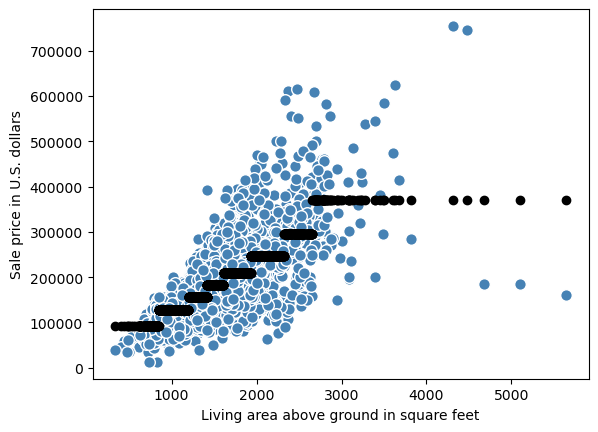

In [32]:
plt.scatter(X, y, c='steelblue', edgecolor='white', s=70)
plt.scatter(X, tree.predict(X), color='k')
plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S. dollars')
plt.show()

As we can see in the resulting plot, the decision tree captures the general trend in the data. However, a limitation of this model is that it does not capture the continuity of the desired prediction. In addition, we need to be careful about choosing an appropriate value for the depth of the tree so as to not overfit or underfit the data. Here, a depth of three seemed to be a good choice.
Note that there are only 8 possible target values predicted by this tree (by counting the different y values of the predictions, black points). This means that the tree has 8 leaves. Let's see these target values.

In [33]:
np.unique(tree.predict(X))

array([ 92551.33333333, 126553.00669344, 155751.11089866, 182551.73125   ,
       209352.88421053, 246675.6702509 , 295797.86821705, 370284.85526316])

## Practice question
Load the iris dataset, split it into train and test, use cross validation on the train set to tune the tree hyperparameters. Evaluate the performance and visualize the selected tree.

# Ensemble Methods

The goal of ensemble methods is to combine different classifiers into a meta-classifier that has better generalization performance than each individual classifier alone. There are several different 
approaches for creating an ensemble of classifier, as we will see throughout this notebook..

## Voting classifiers

A very simple way to create a better classifier is to aggregate the predictions of each classifier and predict the class that gets the most votes. The *VotingClassifier* takes in a list of different estimators as arguments and a voting method. The *hard* voting method uses the predicted labels and a majority rules system, while the *soft* voting method chooses a class that gives the largest predicted value of the sum () of the predicted probabilities.

Let's first make a small synthetic dataset, and split it into train and test.

In [34]:
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0,  n_classes=2,
                            n_clusters_per_class=1,   class_sep=0.3, random_state=123)
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=123)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

After defining the classifiers, we need to fit the resulting ensemble classifier object. Note, here we will use Nearest Neighbors classifier which will be covered in the next lecture.

In [36]:
voting = VotingClassifier(
    [('logreg', LogisticRegression(C=0.01, solver='liblinear')),
     ('tree', DecisionTreeClassifier(max_depth = 3, random_state=0)),
     ('knn', KNeighborsClassifier(n_neighbors = 3))],
    voting='hard')
voting.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('logreg', ...), ('tree', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


One attribute of the `VotingClassifier` is `estimators_` which returns the collection of fitted sub-estimators, in the order we specified them.
Let's check the accuracy of the individual estimators and the ensemble. 
Recall that `sklearn` estimators have a  `score` method providing a default evaluation criterion for the problem they are designed to solve. In the case of each of the classifiers above, the `score` returns the accuracy on the given test data and labels.

In [37]:
lr, tree, knn = voting.estimators_
print('Accuracy of Logistic Regression', lr.score(X_test, y_test))
print('Accuracy of Decision Tree', tree.score(X_test, y_test))
print('Accuracy of K Nearest Neighbor ', knn.score(X_test, y_test))
print('Accuracy of the voting ensemble',voting.score(X_test, y_test))

Accuracy of Logistic Regression 0.908
Accuracy of Decision Tree 0.872
Accuracy of K Nearest Neighbor  0.916
Accuracy of the voting ensemble 0.924


Again, we will use *DecisionBoundaryDisplay.from_estimator* to visualize the decision boundary of the subestimators and the ensemble.

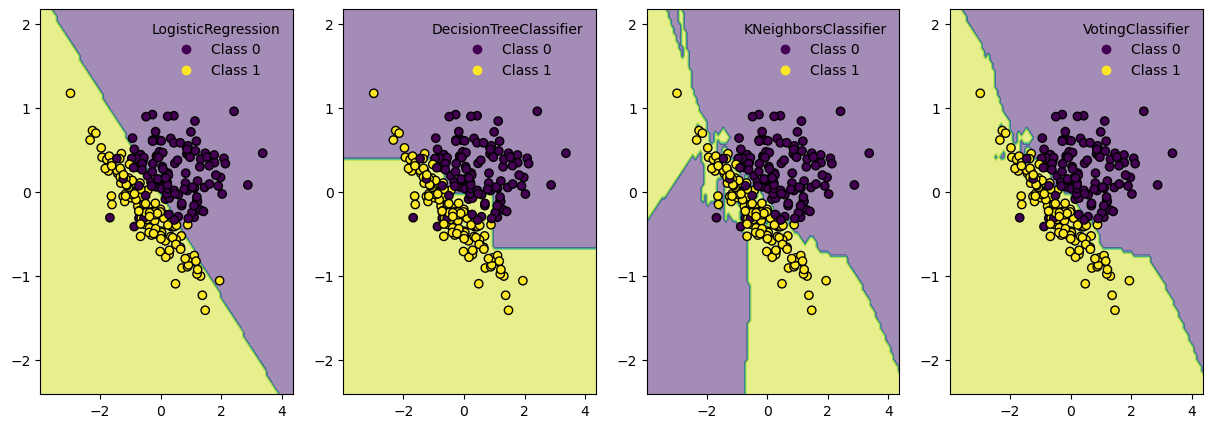

In [38]:
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(15, 5))

for classifier, ax in zip([lr, tree, knn, voting], axs):
        disp = DecisionBoundaryDisplay.from_estimator(classifier, X_test, response_method="predict", alpha=0.5, ax=ax)
        scatter=ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k")
        handles, labels = scatter.legend_elements()
        ax.legend(handles=handles, labels=["Class 0", "Class 1"], title=f"{classifier.__class__.__name__}", frameon=False)

Note that we used  the expression `estimator.__class__.__name__ ` to obtain the name of the class to which an estimator (a model or transformer) belongs, as a string.
Looking at the plots, we can see the liner decision boundary of the logistic regression, decision boundary of the tree orthogonal to the axes, the irregular boundary of the 3-nearest neighbors, and the final decision boundary of the voting classifier, as a combination of the three classifiers.

If all classifiers are able to estimate class probabilities (i.e., they have a *predict_proba()* method), we can use *sklearn* to predict the class with the highest class probability, averaged over all the individual classifiers. This is called *soft* voting. It often achieves higher performance than hard voting because it gives more weight to highly confident votes. All we need to do is replace *voting="hard"* with *voting="soft"* and ensure that all classifiers can estimate class probabilities. 

In [39]:
voting = VotingClassifier(
    [('logreg', LogisticRegression(C=0.01,solver='liblinear')),
     ('tree', DecisionTreeClassifier(max_depth=3, random_state=0)),
     ('knn', KNeighborsClassifier(n_neighbors = 3))],
    voting='soft')
voting.fit(X_train, y_train)
lr, tree, knn = voting.estimators_

In [40]:
lr, tree, knn = voting.estimators_
print('Accuracy of Logistic Regression', lr.score(X_test, y_test))
print('Accuracy of Decision Tree', tree.score(X_test, y_test) )
print('Accuracy of K Nearest Neighbor ', knn.score(X_test, y_test))
print('Accuracy of the voting ensemble', voting.score(X_test, y_test) )

Accuracy of Logistic Regression 0.908
Accuracy of Decision Tree 0.872
Accuracy of K Nearest Neighbor  0.916
Accuracy of the voting ensemble 0.936


In this case using class probabilities gave better results than using labels, and our voting classifier has better accuracy than the base classifiers.

## Bagging

The following follows: https://jakevdp.github.io/PythonDataScienceHandbook/05.08-random-forests.html

One way to get a diverse set of classifiers is to use very different training algorithms as just discussed. Another approach is to use the same training algorithm for every predictor, but to train them on different random subsets of the training set. When sampling is performed with replacement, this method is called bagging (short for bootstrap aggregating). Bagging allows training instances to be sampled several times for the same predictor.

Once all predictors are trained, the ensemble can make a prediction for a new instance by simply aggregating the predictions by hard or soft voting for classification, or the average for regression. Generally, the net result is that the ensemble has a similar bias but a lower variance than a single predictor trained on the original training set.
Bagging makes use of an ensemble  of parallel estimators, each of which over-fits the data, and averages the results to find a better classification. An ensemble of randomized decision trees is known as a random forest.

Let's first generate and visualize a small synthetic dataset with two features using `make_blobs`.

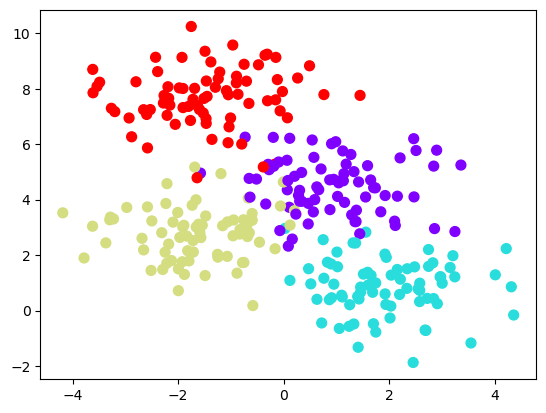

In [41]:
X, y = make_blobs(n_samples=300, centers=4, random_state=0, cluster_std=1.0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow');

Let's check number of members of each class:

In [42]:
pd.Series(y).value_counts()

1    75
3    75
0    75
2    75
Name: count, dtype: int64

Let's fit a simple decision tree and visualize the decision boundaries.

Text(0.5, 1.0, 'Single decision tree')

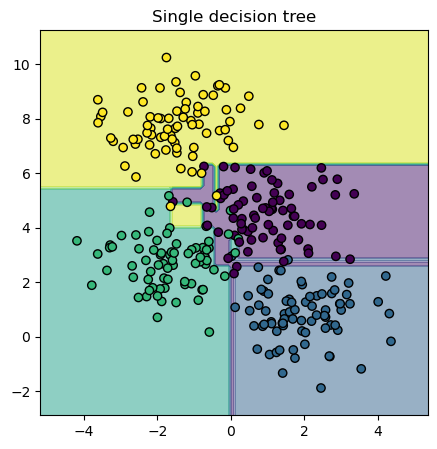

In [43]:
plt.figure(figsize=(5,5))
ax = plt.axes()
tree = DecisionTreeClassifier()
tree.fit(X, y)
disp = DecisionBoundaryDisplay.from_estimator(tree, X, response_method="predict", alpha=0.5, ax=ax)
scatter=ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
handles, labels = scatter.legend_elements()
ax.set_title("Single decision tree")

Bagging classification can be done manually using *sklearn*'s *BaggingClassifier* meta-estimator, as shown here:

Text(0.5, 1.0, 'Ensemble of trees by bagging')

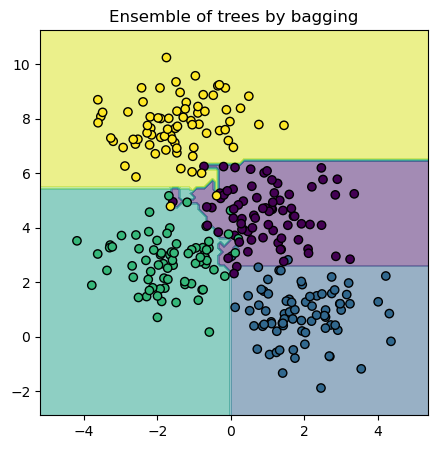

In [44]:
from sklearn.ensemble import BaggingClassifier

tree = DecisionTreeClassifier()
bag = BaggingClassifier(tree, n_estimators=100, max_samples=0.8, random_state=1)
bag.fit(X, y)

plt.figure(figsize=(5,5))
ax = plt.axes()
disp = DecisionBoundaryDisplay.from_estimator(bag, X, response_method="predict", alpha=0.5, ax=ax)
scatter=ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
handles, labels = scatter.legend_elements()
ax.set_title("Ensemble of trees by bagging")

In this example, we have randomized the data by fitting each estimator with a random subset of 80% of the training points. Then the final decision is based on voting (since this is classification, and if it was regression, it would be based on averaging). The default value of the parameter *bootstrap* is True, meaning, unless specified differently, samples are drawn with replacement. 

### Out-of-Bag evaluation

With bagging, some instances may be sampled several times for any given predictor, while others may not be sampled at all. By default a `BaggingClassifier` samples `max_samples` training instances with replacement (`bootstrap=True`), where `max_samples` is the size of the training set (can be set as a number or as a percentage of samples). This means that only about 63% of the training instances are sampled on average for each predictor. The remaining around 37% of the training instances that are not sampled are called out-of-bag (oob) instances. Note that they are not the same 37% for all predictors.

This is because the probability of selecting a given instance is $\dfrac{1}{n}$, and the probability of not selecting said instance is $\left(1 - \dfrac{1}{n}\right)$; then the probability of the instance not being selected n times, i.e., not being selected at all for any predictor during bootstrap sampling is $\left(1 - \dfrac{1}{n}\right)^n$. As $n$ approaches infinity, this expression converges to $\dfrac{1}{e} \approx 0.37$.


Since a predictor never sees the oob instances during training, it can be evaluated on these instances, without the need for a separate validation set or cross-validation. We can evaluate the ensemble itself by averaging out the oob evaluations of each predictor. Note that, while  the oob score is calculated using all the trees in the `BaggingClassifier`, each data instance's oob prediction is only made from the trees that did not have that instance in their bootstrap sample. This means that each instance is predicted by a subset of all trees, specifically those for which the instance was out-of-bag. The final oob score is an aggregation (e.g., mean) of these individual oob predictions.

In `sklearn`, we can set `oob_score=True` when creating a `BaggingClassifier` to request an automatic oob evaluation after training. The following code demonstrates this. The resulting evaluation score is available through the `oob_score_` variable:

In [45]:
bag = BaggingClassifier(tree, n_estimators=100, max_samples=0.8, random_state=1,  oob_score=True)
bag.fit(X, y)
bag.oob_score_

0.91

Note that this is different than if we simply checked the score of the bagging classifier on the training set X:

In [46]:
bag.score(X,y)

0.9966666666666667

### Random Forest

In the previous example, we have randomized the data by fitting each estimator with a random subset of 80% of the training points. In practice, decision trees are additionally randomized by injecting some stochasticity in how the splits are chosen.

In *sklearn*, such an optimized ensemble of randomized decision trees is implemented in the *RandomForestClassifier* estimator, which takes care of all the randomization automatically. When splitting each node during the construction of a tree, the best split is found either from all input features or a random subset of defined by the input parameter, *max_features* (default values is square root of the number of features). The *sklearn* implementation combines classifiers by averaging their probabilistic prediction, instead of letting each classifier vote for a single class.

Random Forest implementation also features the parallel construction of the trees and the parallel computation of the predictions through the n_jobs parameter. As we know, if *n_jobs=k* then computations are partitioned into k jobs, and run on k cores of the machine. If *n_jobs=-1* then all cores available on the machine are used. Note that because of inter-process communication overhead, the speedup might not be linear (i.e., using k jobs will unfortunately not be k times as fast). Significant speedup can still be achieved though when building a large number of trees, or when building a single tree requires a fair amount of time (e.g., on large datasets).  By default, *n_jobs* parameter has value 1. 

Text(0.5, 1.0, 'Random Forest')

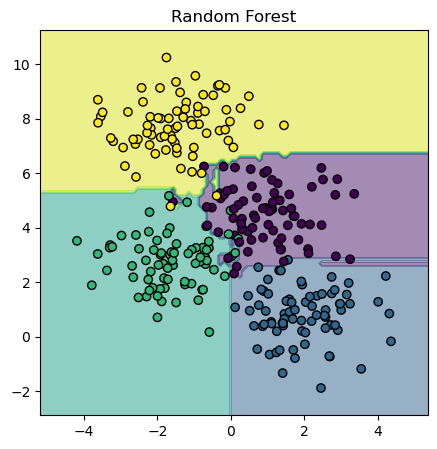

In [47]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X, y)

plt.figure(figsize=(5,5))
ax = plt.axes()
disp = DecisionBoundaryDisplay.from_estimator(model, X, response_method="predict", alpha=0.5, ax=ax)
scatter=ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
handles, labels = scatter.legend_elements()
ax.set_title("Random Forest")

We will use the hand-written digits data to see how the random forest classifier can be used in this context.

In [48]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

Let's visualize the first few digits and their labels:

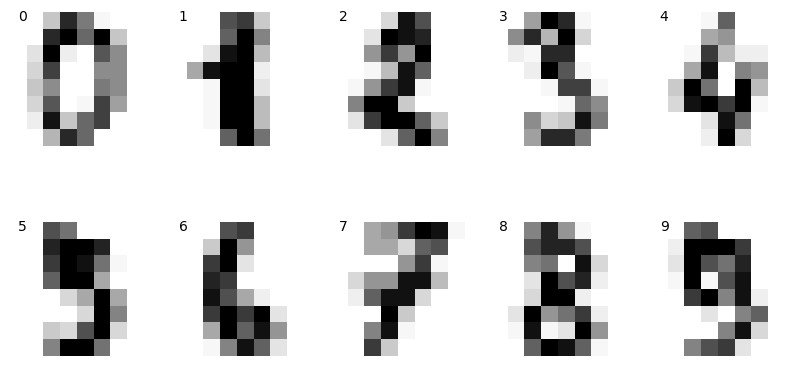

In [49]:
from sklearn.datasets import load_digits
digits = load_digits()
fig, axs = plt.subplots(2, 5, figsize=(10, 5))
for ax, img, target in zip(axs.flat, digits.images, digits.target):
    ax.imshow(img, cmap='Greys')
    ax.axis('off')
    ax.text(0, 0, str(target))

Now, let's use Random Forest.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, random_state=0)
model = RandomForestClassifier(n_estimators=1000, oob_score=True)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

We can take a look at the classification report for this classifier:

In [51]:
from sklearn.metrics import classification_report
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        38
           1       0.98      0.98      0.98        43
           2       0.98      1.00      0.99        43
           3       0.98      1.00      0.99        44
           4       0.97      1.00      0.99        37
           5       0.98      0.96      0.97        49
           6       1.00      1.00      1.00        52
           7       1.00      0.96      0.98        50
           8       0.96      0.98      0.97        47
           9       0.98      0.98      0.98        47

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



Let's also visualize the confusion matrix:

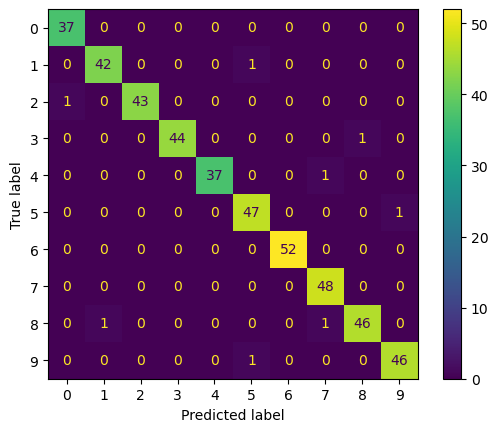

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm=confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

Let's now check out of the estimate of generalization accuracy using out-of-bag samples:

In [53]:
model.oob_score_

0.9740163325909429

We can see that oob samples give us a good estimate: 0.976 is oob_score and accuracy on the test set is 0.98.

We find that a simple, untuned random forest results in a very accurate classification of the digits data.

## Boosting
The general idea of most boosting methods is to train predictors sequentially, each trying to correct its predecessor.
There are many boosting methods available.
Install the following in your environment:

`pip install xgboost lightgbm catboost`

In [54]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

Now, let's trains an AdaBoost classifier based on 200 Decision Stumps using `sklearn`'s `AdaBoostClassifier` class ( there is also an `AdaBoostRegressor` class). A decision stump is a Decision Tree with *max_depth=1*: a tree composed of a single decision node plus two leaf nodes. This is the default base estimator for the `AdaBoostClassifier` class:

In [55]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=200,  learning_rate=0.5, random_state=42)
ada.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",200
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


Let's now visualize the decision boundaries:

Text(0.5, 1.0, 'Ada Boost')

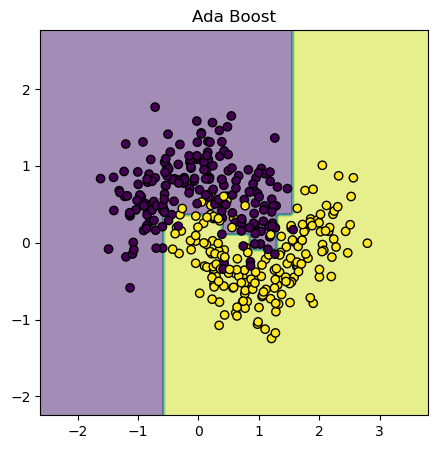

In [56]:
plt.figure(figsize=(5,5))
ax = plt.axes()
disp = DecisionBoundaryDisplay.from_estimator(ada, X_train, response_method="predict", alpha=0.5, ax=ax)
scatter=ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k")
handles, labels = scatter.legend_elements()
ax.set_title("Ada Boost")

### Gradient Boosting

Gradient Boosting works by sequentially adding predictors to an ensemble, each one correcting its predecessor, i.e., this method tries to fit the new predictor to the residual errors made by the previous predictor.

First, let's create a small synthetic dataset using `make_classification`.

In [57]:
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=5, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=49)
print(X.shape, y.shape)

(1000, 10) (1000,)


The *sklearn* library provides the GBM algorithm for regression and classification via the `GradientBoostingClassifier` and `GradientBoostingRegressor` classes. 

Much like the `RandomForestClassifier` class, it has hyperparameters to control the growth of Decision Trees (e.g., max_depth, min_samples_leaf, ...), as well as hyperparameters to control the ensemble training, such as the number of trees (n_estimators). 

Let's first fit `GradientBoostingClassifier` without any parameter tuning.

In [58]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train, y_train)
y_pred_prob= gbc.predict_proba(X_test)
roc_auc_score(y_test, y_pred_prob[:,1]) 

0.9762609366958311

Now, let's tune the model using `RandomizedSearchCV` and check the test error. Note that we are checking the test error for illustrative purposes, and not to do model selection. As we know, test error is evaluated only once for the final selected model, and no modeling decisions should be based on the test set.

Recall that in `RandomizedSearchCV`, in contrast to `GridSearchCV`, not all parameter values are tried out, but rather a fixed number of parameter settings is sampled from the specified distributions. The number of parameter settings that are tried is given by *n_iter*.
The parameter *n_iter* trades off runtime vs quality of the solution. Here we are not going to use large value of *n_iter* so the code should run relatively quickly. In practice, this value should be higher and more parameters should be optimized, and wider parameter range should be sampled.

Additionally, here we are optimizing using the *scoring='roc_auc'*. The scoring method should be chosen carefully, depending on the problem we are solving.

In [59]:
from sklearn.model_selection import RandomizedSearchCV  
param_grid = {'learning_rate': [0.1,0.05,0.03,0.01],                              
              'max_depth': [3,5,7],               
              'max_features': [0.6,0.8,1.0],               
              'min_samples_leaf': [1,2,3,5],               
              'n_estimators': [100, 200]            }  
random_search = RandomizedSearchCV(GradientBoostingClassifier(), param_distributions = param_grid, cv=5, 
                                   n_iter=20, random_state=42,scoring='roc_auc', n_jobs=-1) 
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.1, 0.05, ...], 'max_depth': [3, 5, ...], 'max_features': [0.6, 0.8, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here..

Let's see the best parameters found by randomized search.

In [60]:
print(random_search.best_params_)

{'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 0.6, 'max_depth': 7, 'learning_rate': 0.03}


Now, let's evaluate the ROC AUC score of the test set.

In [61]:
y_pred_prob= random_search.best_estimator_.predict_proba(X_test)
roc_auc_score(y_test, y_pred_prob[:,1]) 

0.9866186309830159

### XGBoost
XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible and portable. It implements machine learning algorithms under the Gradient Boosting framework. It is one of the most popular libraries in practice, since with careful tuning, it often has superior performance compared to other algorithms when applied to structured data. It can be installed as follows:

Here are some XGBoost specifics:

- Parallelized Tree Building: In boositing, trees are built sequentially and thus cannot be created in parallel as in the Random Forest algorithm; however, XGBoost still leverages parallelism—thereby gaining speed—by adding it to the construction of individual trees: within a single tree, XGBoost parallelizes the creation of branches, since each node in the decision tree corresponds to a particular feature and a split point and, therefore, XGBoost can evaluate potential splits for different features concurrently using multiple CPU cores.
<div style="margin-top: 10px;"></div>

- Regularization: In contrast to GBM, XGBoost implements the L1 Regularization (Lasso) and L2 Regularization (Ridge) methods that allow it to address overfitting better than its predecessor.
<div style="margin-top: 10px;"></div>

In [62]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred_prob= xgb.predict_proba(X_test)
roc_auc_score(y_test, y_pred_prob[:,1]) 

0.9758749356664952

Xgboost has many hyperparameters, full list is available at:
    
https://xgboost.readthedocs.io/en/latest/parameter.html#general-parameters

Much attention should be given to model tuning. However, here we are only going to use a small randomized search.
An example of more detailed tuning is available at:
https://www.analyticsvidhya.com/blog/2016/03/complete-guide-parameter-tuning-xgboost-with-codes-python/

Note: to sample from values uniformly, we will use `scipy.stats.uniform` function.  Recall that using the parameters `loc` and `scale`, we can obtain the uniform distribution on `[loc, loc + scale]`.



In [63]:
from scipy.stats import uniform as sp_uniform
param_grid= {
        'max_depth': [6, 10, 15, 20],
        'learning_rate': [0.001, 0.01, 0.1, 0.2, 0,3],
        'subsample': sp_uniform(loc=0.2, scale=0.8),
        'colsample_bytree': sp_uniform(loc=0.4, scale=0.6),
        'colsample_bylevel': sp_uniform(loc=0.4, scale=0.6),
        'min_child_weight': [0.5, 1.0, 3.0, 5.0],
        'gamma': [0, 0.1, 0.25, 0.5, 1.0],
        'reg_lambda': [0, 1e-1, 1, 2, 5, 7, 10],
        'n_estimators': [100,150, 200,300, 400]
        }
xgb = XGBClassifier()
random_search = RandomizedSearchCV(xgb, param_distributions = param_grid,cv=5,n_iter=20, random_state=42, scoring='roc_auc', n_jobs=-1) 
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bylevel': <scipy.stats....00169E5289F90>, 'colsample_bytree': <scipy.stats....00169E528A5D0>, 'gamma': [0, 0.1, ...], 'learning_rate': [0.001, 0.01, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-va

Let's see the best parameters found by the randomized search:

In [64]:
print(random_search.best_params_)

{'colsample_bylevel': np.float64(0.6562646731757538), 'colsample_bytree': np.float64(0.8908088595534959), 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 15, 'min_child_weight': 1.0, 'n_estimators': 200, 'reg_lambda': 0, 'subsample': np.float64(0.5878639770871865)}


Let's check the metric on the test set:

In [65]:
y_pred_prob= random_search.best_estimator_.predict_proba(X_test)
roc_auc_score(y_test, y_pred_prob[:,1]) 

0.978834276891405

### LightGBM

LightGBM is another gradient boosting framework that uses tree based learning algorithms and is widely used in practice. It is designed to be distributed and efficient. The library is installed as follows:

LightGBM benefits from enhancements that were also included in XGBoost and it introduces additional optimizations that set it apart. Some of the most important are the following:

- "Leaf-wise" Criterion: LightGBM adopts a leaf-wise growth stategy, in contrast to the usual level-wise approach whereby all nodes are expanded at each level. This is faster than the level-wise method and tends to culminates in deeper but narrower trees that can offer flexibility to capture complex feature relationships, but it can also lead to overfitting.

-  Generally, LightGBM is faster and uses less memory than XGBoost, particularly because of its leaf-wise tree growth algorithm and data structure optimizations. 

- LightGBM natively supports categorical features, meaning it can handle them without manual preprocessing into numerical dummy variables, however these categorical features must be specified with `categorical_feature` parameter and must be encoded as integers.

In [66]:
from lightgbm.sklearn import LGBMClassifier

lgbm = LGBMClassifier(verbosity=-1)
lgbm.fit(X_train, y_train)
y_pred_prob= lgbm.predict_proba(X_test)
roc_auc_score(y_test, y_pred_prob[:,1]) 

C:\ProgramData\anaconda3\envs\ml2026\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9815362840967576

LightGBM also has many parameters that need to be tuned. Please check the documentation:
https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html

### CatBoost

CatBoost is yet another gradient boosting framework that uses tree based learning algorithms and is widely used in practice.
This library should be installed as follows:

Documentation is available at:
https://catboost.ai/en/docs/concepts/python-quickstart

 Catboost shares similarities with its counterparts as well (regularizations, handling of missing data, etc., but it also has some innovations:

- CatBoost has even more support for catgorical features compared to LightGBM, it uses an advanced algorithm to process categorical variables, reducing the need for extensive data preprocessing and potentially leading to better performance, especially in datasets with many categorical features. Here,  there is no need for encoding beforehand. It employs various strategies, such as target-based encoding.

- Symmetric Trees: Symmetric decision trees employ the same threshold and feature to each node on the same level of the tree. Although these trees are worse predictors, the idea of gradient boosting is to combine weak learners to arrive at an optimal decision, and these trees fulfill that criterion while being faster at predicting than normal trees. 

- Ordered Boosting: In order to prevent overfitting, Catboost employs ordered boosting: unlike traditional boosting algorithms that leverage the same data for residual estimation as the data used to train the model, ordered boosting divides a given dataset into random permutations and trains each learner on one subset of the data while calculating the residuals on another.

First, we will show how to fit the *CatBoostClassifier* with no tuning.

In [67]:
from catboost import CatBoostClassifier

catb = CatBoostClassifier(verbose=False, iterations=100)
catb.fit(X_train, y_train)
y_pred_prob= catb.predict_proba(X_test)
roc_auc_score(y_test, y_pred_prob[:,1]) 

0.9817292846114256

Catboost has many different parameters that should be tuned. The full list is available at:
    
https://catboost.ai/docs/concepts/parameter-tuning.html
    
As in other gradient boosting libraries, much attention and time should be given to model tuning. Here, for illustrative purposes, we are only going to optimize a few parameters.

In [68]:
param_grid= {'learning_rate': [0.1,0.05,0.03,0.01],
        'depth': [3, 5,7],
        'l2_leaf_reg': [1, 3, 5, 7, 9] }
random_search = RandomizedSearchCV(CatBoostClassifier(verbose=False,iterations=100), param_distributions = param_grid,
                                   cv=5, n_iter=20, random_state=42, scoring='roc_auc', n_jobs=-1) 
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CatBoostClass...verbose=False)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'depth': [3, 5, ...], 'l2_leaf_reg': [1, 3, ...], 'learning_rate': [0.1, 0.05, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value 

Let's see the best parameters found by the randomized search:

In [69]:
print(random_search.best_params_)

{'learning_rate': 0.1, 'l2_leaf_reg': 1, 'depth': 7}


Let's check the metric on the test set:

In [70]:
y_pred_prob= random_search.best_estimator_.predict_proba(X_test)
roc_auc_score(y_test, y_pred_prob[:,1]) 

0.9837236232629953

# Adjusting weights of the minority class

Class imbalance often leads to models that are biased towards the majority class, as the learning process may prioritize minimizing errors on the dominant class(es). In the previous notebook we saw different ways of balancing the data. However, here we will illustrate an approch of adjusting the weights, encouraging the model to pay more attention to minority instances during the training process.

In XGBoost a parameter that adjusts class weighting is `scale_pos_weight`.  Typically, it is set as the ratio of number of instances od negative class to the positive class:

`scale_pos_weight`=$\frac{\text{Number of Negative Samples}}{\text{Number of Positive Samples}}$



Here is an illustrative examples using a toy imbalanced dataset.

In [71]:
X, y = make_classification(n_samples=2000, n_features=20, n_classes=2, 
                           weights=[0.95, 0.05], random_state=42)

Let's check the class distribution in the original dataset.

In [72]:
pd.Series(y).value_counts(normalize=True)

0    0.9465
1    0.0535
Name: proportion, dtype: float64

We will use stratified split to ensure that both the training and the test set maintain the same proportion of classes as in the original dataset.

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

We will confirm that the class distribution stays the same after the split in both training and the test dataset:

In [74]:
pd.Series(y_train).value_counts(normalize=True)

0    0.94625
1    0.05375
Name: proportion, dtype: float64

In [75]:
pd.Series(y_test).value_counts(normalize=True)

0    0.9475
1    0.0525
Name: proportion, dtype: float64

Now, since the goal is just to illustrate the use of the weighing parameter, we will not tune the model, though in practice, we should always do so. First we will train an ordinary xgboost that weighs both classes the same.

In [76]:
model_default = XGBClassifier(n_estimators=100, random_state=42)
model_default.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

Next we will set the weight as the ratio of data points in class 0 and the datapoints of class 1:

In [77]:
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
scale_pos_weight

np.float64(17.6046511627907)

By default, the `scale_pos_weight` hyperparameter is set to the value of 1 and has the effect of weighing the balance of positive examples, relative to negative examples when boosting decision trees. Next, we train another XGboost model, but this time specifying weight higher than 1 for positive class, which increases the penalty for misclassifying this class.

In [78]:
model_weighted = XGBClassifier(scale_pos_weight=scale_pos_weight, n_estimators=100, random_state=42)
model_weighted.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

Let's evaluate both of these models:

In [79]:
y_pred_default = model_default.predict(X_test)
y_pred_weighted = model_weighted.predict(X_test)

print("Model without scale_pos_weight:")
print(classification_report(y_test, y_pred_default))

print("Model with scale_pos_weight:")
print(classification_report(y_test, y_pred_weighted))


Model without scale_pos_weight:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       379
           1       0.75      0.43      0.55        21

    accuracy                           0.96       400
   macro avg       0.86      0.71      0.76       400
weighted avg       0.96      0.96      0.96       400

Model with scale_pos_weight:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       379
           1       0.73      0.52      0.61        21

    accuracy                           0.96       400
   macro avg       0.85      0.76      0.80       400
weighted avg       0.96      0.96      0.96       400



Both models preform really well on this toy problem, but the weighted model (with scale_pos_weight) slightly improves recall, 0.52 compared to 0.43 for the minority class (fewer false negatives).
However, it also slightly reduced precision, since the model is more sensitive to positive cases, and the precision falls from 0.75 to 0.69.

This heuristic for setting the scale_pos_weight is effective for many situations. However, it is possible that better performance can be achieved with a different class weighting, and this too will depend on the choice of performance metric used to evaluate the model. Hence, the value of this hyperparameter should be tuned with cross validation.

## Key points

To use decision trees in `sklearn`:
- classification `DecisionTreeClassifier`
- regression: `DecisionTreeRegressor`

Parameters of decision trees:
- `max_depth`: maximum depth of the tree
-  `min_samples_leaf`: minimum samples per leaf
-  `criterion`: splitting criterion

Ensemble methods in `sklearn`:
- `VotingClassifier` takes in a list of different estimators as arguments and a voting method: `hard` voting uses the predicted labels and a majority, `soft` voting method chooses a class that gives the largest predicted value of the sum of the predicted probabilities.
- `RandomForestClassifier` or  `RandomForestRegressor`
- `XGBClassifier` or  `XGBoostRegressor`
- `LGBMClassifier` or `LGBMRegressor`
- `CatBoostClassifier` or `CatBoostRegressor`

One way to deal with class imbalance is to adjust the weight of each class, forcing the model to pay more attention to minority class. Example:
- parameter `scale_pos_weight` in `XGBClassifier`